# 07 – Komplexe Zahlen: Signalleistung und Energie (Beispiel)

Dieses Vertiefungsnotebook löst eine konkrete **Aufgabe aus der Signal- und Leistungsberechnung** (Bezug: Vorlesung **02 – Signale und Spektren**). Du lernst, wie man die **durchschnittliche Signalleistung** und die **Gesamtenergie** über eine Zeitspanne berechnet – und wie **komplexe Zahlen** in Python den Rechenweg vereinfachen.

**Navigation:** [← 07_Komplexe_Zahlen (Hauptkapitel)](07_Komplexe_Zahlen.ipynb) | Beispiel Signalleistung & Energie

## Präzise Aufgabenstellung

**Gegeben:**
- **Signal 1 (Realteil):** Sinussignal mit Amplitude $A_1 = 0{,}8\,\mathrm{V}$ und Frequenz $f_1 = 2\,\mathrm{Hz}$.
  - $v_1(t) = A_1 \cdot \cos(2\pi f_1 t)$
- **Signal 2 (Imaginärteil):** Sinussignal mit **30° Phasennacheilung**, Amplitude $A_2 = 0{,}9\,\mathrm{V}$ und Frequenz $f_2 = 3\,\mathrm{Hz}$.
  - $v_2(t) = A_2 \cdot \cos(2\pi f_2 t - 30°)$, mit $30° = \pi/6\,\mathrm{rad}$.
- **Zeitdauer:** $T = 10\,\mathrm{s}$, **1000 Abtastwerte** (Abtastintervall $\Delta t = T/N = 0{,}01\,\mathrm{s}$).
- **Annahme:** Die Amplituden sind in **Volt** skaliert; **Bezugswiderstand** $R = 50\,\Omega$.

**Aufgabe:**
1. Beide Signale in einem gemeinsamen Matplotlib-Plot darstellen.
2. Die **durchschnittliche Signalleistung** $P_{\mathrm{avg}}$ über die Zeitspanne $T$ berechnen.
3. Die **Gesamtenergie** $E$ über $T$ berechnen.

**Hinweis:** Bei unterschiedlichen Frequenzen sind die beiden Anteile über die Zeit orthogonal; die mittlere Leistung ist die Summe der mittleren Leistungen der beiden Teilspannungen (je $P_{\mathrm{avg},k} = A_k^2/(2R)$).

## Theorie: Leistung und Energie

**Momentanleistung** (an $R$):
$$ p(t) = \frac{v(t)^2}{R} $$

Für ein **reelles Sinussignal** $v(t) = A\cos(2\pi f t + \varphi)$ gilt für die **mittlere Leistung**:
$$ P_{\mathrm{avg}} = \frac{A^2}{2R} $$

**Gesamtenergie** über $T$:
$$ E = \int_0^T p(t)\,\mathrm{d}t \approx \sum_{n=0}^{N-1} p(t_n)\,\Delta t $$

Im stationären Fall: $E = P_{\mathrm{avg}} \cdot T$.

## Vereinfachter Weg mit komplexem Signal

Wir fassen die beiden reellen Signale zu einem **komplexen Signal** zusammen:
$$ z(t) = v_1(t) + \mathrm{j}\,v_2(t) $$

Dann gilt:
$$ |z(t)|^2 = v_1(t)^2 + v_2(t)^2 $$

Weil $v_1$ und $v_2$ unterschiedliche Frequenzen haben, ist ihr Produkt über $T$ im Mittel null (orthogonal). Die **Momentanleistung** (Summe der Anteile beider Spannungen an $R$) ist:
$$ p(t) = \frac{v_1^2 + v_2^2}{R} = \frac{|z|^2}{R} $$

In Python: Wir bilden $z = v_1 + \mathrm{1j}\,v_2$, berechnen $|z|^2$ mit **`np.abs(z)**2`** (oder `z.real**2 + z.imag**2`) und daraus $p(t)$, $P_{\mathrm{avg}}$ und $E$. So brauchen wir keine getrennten Variablen für $v_1^2$ und $v_2^2$ – ein komplexes Array reicht.

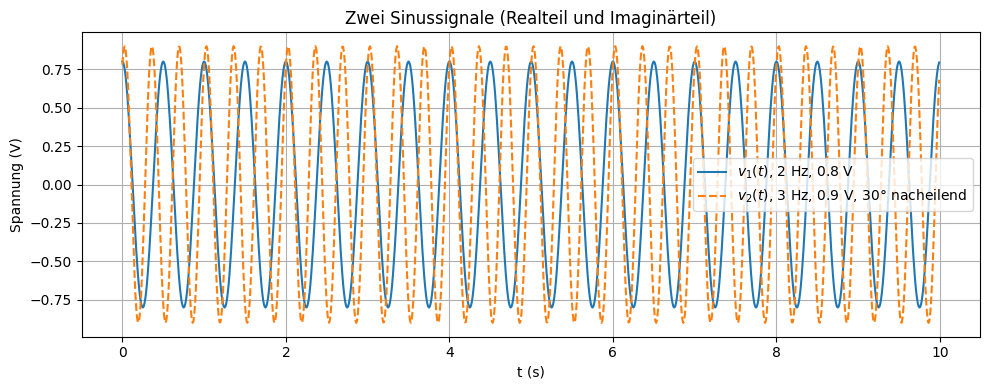

In [1]:
import numpy as np
import matplotlib.pyplot as plt

A1, f1 = 0.8, 2.0
A2, f2 = 0.9, 3.0
phase2_rad = np.deg2rad(30)
T = 10.0
N = 1000
R = 50.0

t = np.linspace(0, T, N, endpoint=False)
dt = T / N

v1 = A1 * np.cos(2 * np.pi * f1 * t)
v2 = A2 * np.cos(2 * np.pi * f2 * t - phase2_rad)

plt.figure(figsize=(10, 4))
plt.plot(t, v1, label=r"$v_1(t)$, 2 Hz, 0.8 V", color="C0")
plt.plot(t, v2, label=r"$v_2(t)$, 3 Hz, 0.9 V, 30° nacheilend", color="C1", linestyle="--")
plt.xlabel("t (s)")
plt.ylabel("Spannung (V)")
plt.title("Zwei Sinussignale (Realteil und Imaginärteil)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Leistung und Energie: mit komplexem Signal

Wir bilden $z(t) = v_1 + \mathrm{j}\,v_2$ und nutzen $|z|^2 = v_1^2 + v_2^2$ für die Momentanleistung.

In [2]:
z = v1 + 1j * v2
p_inst = np.abs(z) ** 2 / R

P_avg = np.mean(p_inst)
E = np.sum(p_inst) * dt

print("Durchschnittliche Signalleistung P_avg =", round(P_avg, 6), "W")
print("Gesamtenergie E über", T, "s =", round(E, 6), "J")
print("Kontrolle: E / T =", round(E / T, 6), "W (sollte P_avg entsprechen)")

Durchschnittliche Signalleistung P_avg = 0.0145 W
Gesamtenergie E über 10.0 s = 0.145 J
Kontrolle: E / T = 0.0145 W (sollte P_avg entsprechen)


## Kontrolle mit der Formel für Sinussignale

Für jedes Sinussignal gilt $P_{\mathrm{avg},k} = A_k^2/(2R)$. Damit:
- $P_1 = 0{,}8^2/(2\cdot 50) = 0{,}0064\,\mathrm{W}$
- $P_2 = 0{,}9^2/(2\cdot 50) = 0{,}0081\,\mathrm{W}$
- $P_{\mathrm{avg}} = P_1 + P_2 = 0{,}0145\,\mathrm{W}$, $E = P_{\mathrm{avg}} \cdot T = 0{,}145\,\mathrm{J}$.

In [3]:
P1_formel = A1**2 / (2 * R)
P2_formel = A2**2 / (2 * R)
P_avg_formel = P1_formel + P2_formel
E_formel = P_avg_formel * T

print("Aus Formel: P1 =", P1_formel, "W, P2 =", P2_formel, "W")
print("P_avg (Formel) =", P_avg_formel, "W")
print("E (Formel) =", E_formel, "J")

Aus Formel: P1 = 0.006400000000000001 W, P2 = 0.008100000000000001 W
P_avg (Formel) = 0.014500000000000002 W
E (Formel) = 0.14500000000000002 J


Die numerische Auswertung über $|z(t)|^2/R$ und die Formel $A^2/(2R)$ liefern dasselbe Ergebnis (bis auf Abtasteffekte bei endlichem $N$).

---

**Zurück:** [← 07_Komplexe_Zahlen (Hauptkapitel)](07_Komplexe_Zahlen.ipynb)